In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

(0.0, 450000.0)

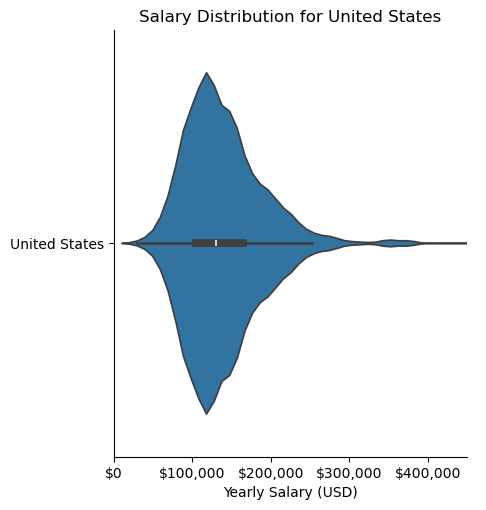

In [42]:
df_us = df.query(
    "job_title_short == 'Data Scientist' and "
    "job_country == 'United States'"
).dropna(subset='salary_year_avg')


sns.catplot(data = df_us, x= 'salary_year_avg', y= 'job_country', kind= 'violin')

ax = plt.gca()
ax.locator_params(axis='x', nbins=7)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${y:,.0f}'))

plt.title('Salary Distribution for United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 450_000)